# Degree = 12 & lambda = 1

e:\Anaconda\Lib\site-packages\sklearn\linear_model\_ridge.py:204: LinAlgWarning: Ill-conditioned matrix (rcond=6.16158e-25): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


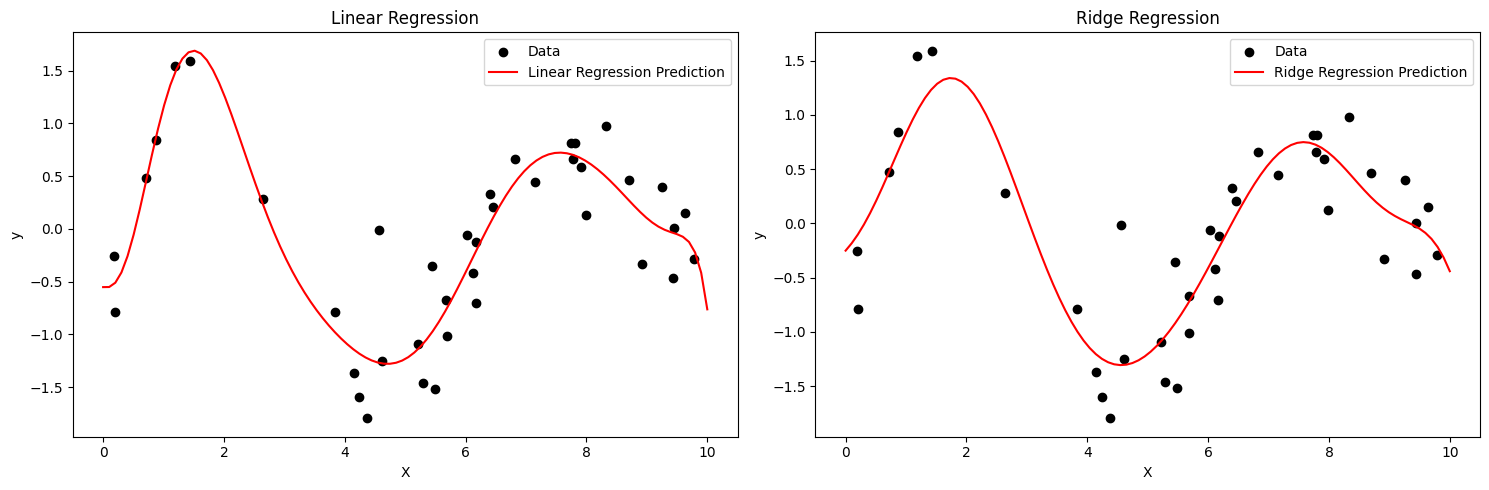

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import PolynomialFeatures #generate polynomials of input data
from sklearn.pipeline import make_pipeline #helps to streamline processes

np.random.seed(0)
X = np.sort(np.random.rand(40, 1) * 10, axis=0)
y = np.sin(X).ravel() + np.random.randn(40) * 0.5

#Setting degree for the regression
degree = 12

#defining models
models = [("Linear Regression", LinearRegression()), ("Ridge Regression", Ridge(alpha = 1))]

#Defining plot
plt.figure(figsize=(15, 5))
X_plot = np.linspace(0, 10, 100).reshape(-1, 1)

for i, (name, model) in enumerate(models):
    poly_model = make_pipeline(PolynomialFeatures(degree), model)
    poly_model.fit(X, y)
    y_pred = poly_model.predict(X_plot)

    plt.subplot(1, 2, i+1)
    plt.scatter(X, y, color='black', label='Data')
    plt.plot(X_plot, y_pred, label=f'{name} Prediction', color='red')
    plt.title(name)
    plt.xlabel("X")
    plt.ylabel("y")
    plt.legend()

plt.tight_layout()
plt.show()

# Degree = 4 & lambda = 100

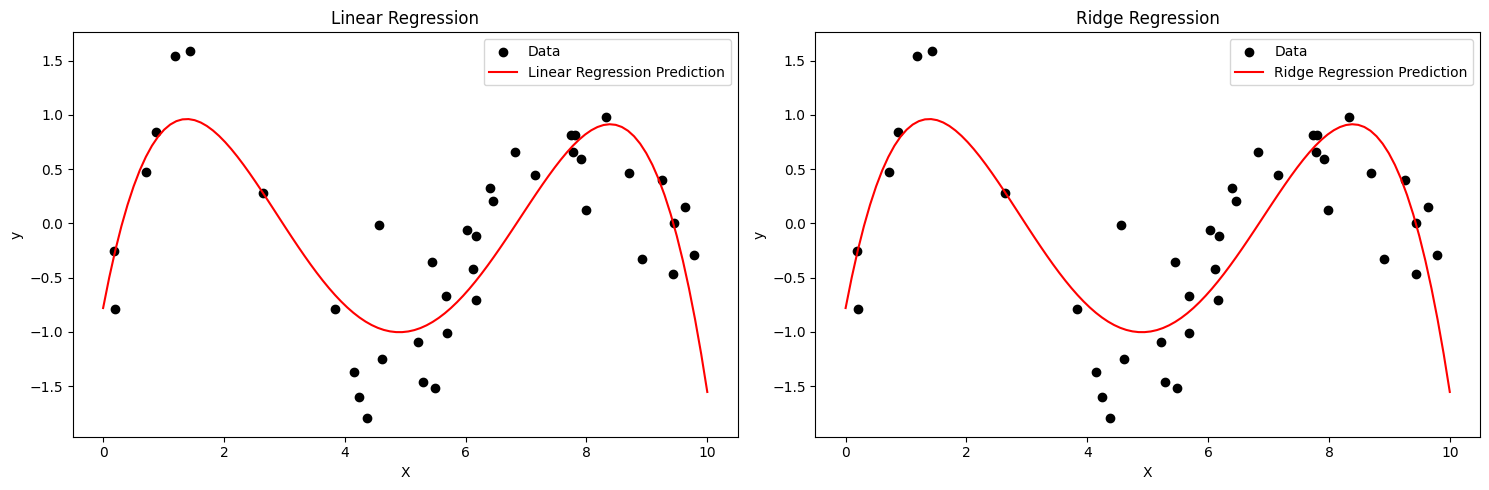

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import PolynomialFeatures #generate polynomials of input data
from sklearn.pipeline import make_pipeline #helps to streamline processes

np.random.seed(0)
X = np.sort(np.random.rand(40, 1) * 10, axis=0)
y = np.sin(X).ravel() + np.random.randn(40) * 0.5

#Seting degree for the regression
degree = 4

#defining models
models = [("Linear Regression", LinearRegression()), ("Ridge Regression", Ridge(alpha = 10))]

#Defining plot
plt.figure(figsize=(15, 5))
X_plot = np.linspace(0, 10, 100).reshape(-1, 1)

for i, (name, model) in enumerate(models):
    poly_model = make_pipeline(PolynomialFeatures(degree), model)
    poly_model.fit(X, y)
    y_pred = poly_model.predict(X_plot)

    plt.subplot(1, 2, i+1)
    plt.scatter(X, y, color='black', label='Data')
    plt.plot(X_plot, y_pred, label=f'{name} Prediction', color='red')
    plt.title(name)
    plt.xlabel("X")
    plt.ylabel("y")
    plt.legend()

plt.tight_layout()
plt.show()

## Grid Search

e:\Anaconda\Lib\site-packages\sklearn\linear_model\_ridge.py:204: LinAlgWarning: Ill-conditioned matrix (rcond=3.67478e-20): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
e:\Anaconda\Lib\site-packages\sklearn\linear_model\_ridge.py:204: LinAlgWarning: Ill-conditioned matrix (rcond=4.73857e-20): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
e:\Anaconda\Lib\site-packages\sklearn\linear_model\_ridge.py:204: LinAlgWarning: Ill-conditioned matrix (rcond=4.65177e-20): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
e:\Anaconda\Lib\site-packages\sklearn\linear_model\_ridge.py:204: LinAlgWarning: Ill-conditioned matrix (rcond=4.39506e-20): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
e:\Anaconda\Lib\site-packages\sklearn\linear_model\_ridge.py:204: LinAlgWarning: Ill-conditioned matrix (rcond=1.05871e-18): res

Best Parameters:
{'model__alpha': 1, 'poly__degree': 4}

Best Score:
1.4562838646216638


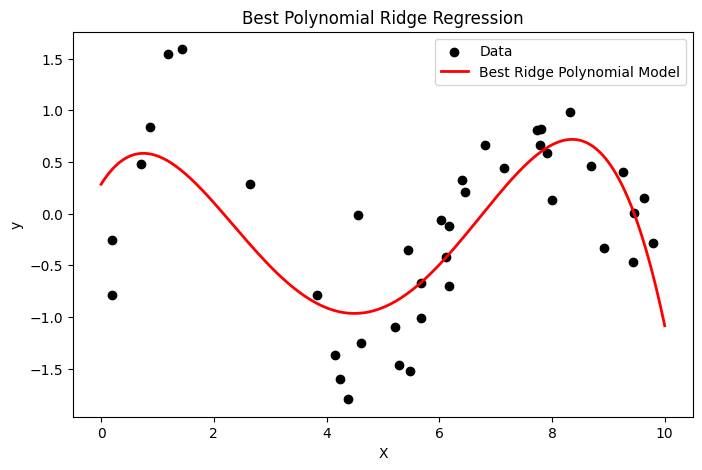

In [3]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error

np.random.seed(0)

X = np.sort(np.random.rand(40, 1) * 10, axis=0)
y = np.sin(X).ravel() + np.random.randn(40) * 0.5

pipeline = Pipeline([
    ('poly', PolynomialFeatures()),
    ('model', Ridge())
])


param_grid = {
    'poly__degree': [3, 4, 5, 6, 8, 10, 12],
    'model__alpha': [0.001, 0.01, 0.1, 1, 10, 100]
}


grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='neg_mean_squared_error'
)

# Train Grid Search
grid_search.fit(X, y)


print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Score:")
print(-grid_search.best_score_)


best_model = grid_search.best_estimator_


X_plot = np.linspace(0, 10, 200).reshape(-1, 1)
y_pred = best_model.predict(X_plot)


plt.figure(figsize=(8,5))

plt.scatter(X, y, color='black', label='Data')
plt.plot(X_plot, y_pred, color='red', linewidth=2,
         label='Best Ridge Polynomial Model')

plt.title("Best Polynomial Ridge Regression")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()

plt.show()

In [8]:
import numpy as np
import plotly.graph_objects as go
import pandas as pd

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

# Generate Dataset
np.random.seed(0)

X = np.sort(np.random.rand(40, 1) * 10, axis=0)
y = np.sin(X).ravel() + np.random.randn(40) * 0.5

# print("Data before Polynomial Features:", X, y)
df_original = pd.DataFrame({
    'x': X.ravel(),
    'y': y
})
df_original.to_csv("original_data.csv", index=False)

degree = 2

poly = PolynomialFeatures(degree=degree, include_bias=False)
X_poly = poly.fit_transform(X)

df_poly = pd.DataFrame({
    'z1_x': X_poly[:, 0],
    'z2_x_squared': X_poly[:, 1],
    'y': y
})

df_poly.to_csv("polynomial_feature_space.csv", index=False)

# X_poly:
# column 0 -> x
# column 1 -> x^2

model = LinearRegression()
model.fit(X_poly, y)

# Create Grid in Higher-Dimensional Space
z1_range = np.linspace(X_poly[:,0].min(), X_poly[:,0].max(), 50)
z2_range = np.linspace(X_poly[:,1].min(), X_poly[:,1].max(), 50)

z1_grid, z2_grid = np.meshgrid(z1_range, z2_range)

# ---------------------------------------------------
# Linear Hyperplane in Feature Space
#
# y = w0 + w1*z1 + w2*z2
# ---------------------------------------------------
y_grid = (
    model.intercept_
    + model.coef_[0] * z1_grid
    + model.coef_[1] * z2_grid
)


fig = go.Figure()

# Data points
fig.add_trace(
    go.Scatter3d(
        x=X_poly[:,0],      # z1 = x
        y=X_poly[:,1],      # z2 = x^2
        z=y,
        mode='markers',
        marker=dict(size=5, color='black'),
        name='Data'
    )
)

# Hyperplane
fig.add_trace(
    go.Surface(
        x=z1_grid,
        y=z2_grid,
        z=y_grid,
        opacity=0.7,
        showscale=False,
        name='Linear Hyperplane'
    )
)

fig.update_layout(
    title="Polynomial Regression as Linear Hyperplane",
    scene=dict(
        xaxis_title='z1 = x',
        yaxis_title='z2 = x²',
        zaxis_title='y'
    ),
    width=900,
    height=700
)

fig.show()